In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import MultiHeadAttention

In [32]:
# Plot settings
plt.style.use("seaborn-v0_8")
sns.set_context("talk")

In [33]:
PROJECT_ROOT = "../"

DATA_PATH = (
    PROJECT_ROOT
    + "ingestion/data/processed/district_flood_ml_dataset.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    + "models/flood_transformer_model.keras"
)

SCALER_PATH = (
    PROJECT_ROOT
    + "models/flood_transformer_scaler.pkl"
)

TIME_STEPS = 14

FEATURES = [
    "rainfall_mm",
    "soil_moisture",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "wind_speed_10m_mean",
    "cloud_cover_mean",
    "is_monsoon",
]

In [34]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"])

scaler = joblib.load(SCALER_PATH)
df[FEATURES] = scaler.transform(df[FEATURES])

# Data verification
print("=" * 60)
print("📊 DATA VERIFICATION")
print("=" * 60)
print(f"Total records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of districts: {df['district'].nunique()}")
print(f"Flood events: {(df['flood_risk'] == 1).sum()}")
print(f"Non-flood events: {(df['flood_risk'] == 0).sum()}")
print(f"\nDistricts with most flood events:")
flood_by_district = df[df['flood_risk'] == 1].groupby('district').size().sort_values(ascending=False)
print(flood_by_district.head(10))
print("=" * 60)

df.head()

📊 DATA VERIFICATION
Total records: 21841
Date range: 2015-01-14 00:00:00 to 2024-12-31 00:00:00
Number of districts: 6
Flood events: 185
Non-flood events: 21656

Districts with most flood events:
district
Chennai         105
Cuddalore        69
Nagapattinam      6
Kancheepuram      5
dtype: int64


,date,district,rainfall_mm,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_mean,cloud_cover_mean,soil_moisture,rain_3d,rain_7d,rain_14d,soil_7d_avg,soil_14d_avg,wetness_index,rain_intensity,month,is_monsoon,flood_risk
0,2015-01-14,Chengalpattu,-0.358809,-2.084918,-0.252362,0.475961,-0.595266,-1.719061,-0.787587,0.0,1.5,4.9,0.221200,0.247726,0.331800,0.000000,1,-1.197763,0
1,2015-01-15,Chengalpattu,-0.358809,-1.887159,0.413642,0.496248,-0.783740,-1.236475,-0.810852,0.0,0.8,4.9,0.212600,0.240214,0.170080,0.000000,1,-1.197763,0
2,2015-01-16,Chengalpattu,-0.278590,-1.531194,0.746644,0.557109,-0.218317,-1.167534,-0.824532,0.7,0.7,4.3,0.203897,0.232474,0.142728,0.998573,1,-1.197763,0
3,2015-01-17,Chengalpattu,-0.358809,-1.452090,0.080640,0.658545,-0.352942,-0.202362,-0.848895,0.7,0.7,3.1,0.195120,0.224243,0.136584,0.000000,1,-1.197763,0
4,2015-01-18,Chengalpattu,-0.358809,-1.728953,-0.252362,0.800554,-0.783740,0.349165,-0.872560,0.7,0.7,2.7,0.186309,0.215880,0.130416,0.000000,1,-1.197763,0


In [35]:
def build_sequences(df, district):
    sub = df[df["district"] == district].sort_values("date")

    X, y, dates = [], [], []

    data = sub[FEATURES].values
    labels = sub["flood_risk"].values
    date_vals = sub["date"].values

    for i in range(TIME_STEPS, len(sub)):
        X.append(data[i - TIME_STEPS:i])
        y.append(labels[i])
        dates.append(date_vals[i])

    return np.array(X), np.array(y), np.array(dates)

In [36]:
model = load_model(MODEL_PATH)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 14, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 8)     │      2,248 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 8)     │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 8)     │         16 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 14, 64)    │        576 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 14, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 14, 8)     │        520 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 8)     │         16 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 8)     │      2,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 14, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 8)     │         16 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 14, 64)    │        576 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 14, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 14, 8)     │        520 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 14, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 14, 8)     │         16 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 8)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        288 │ global_average_p

 Total params: 21,221 (82.90 KB)

 Trainable params: 7,073 (27.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,148 (55.27 KB)

In [37]:
# Locate the MultiHeadAttention layer
attention_layer = None
for layer in model.layers:
    if isinstance(layer, MultiHeadAttention):
        attention_layer = layer
        break

attention_layer

<MultiHeadAttention name=multi_head_attention, built=True>

In [38]:
# Build a custom model to extract attention scores from the FIRST attention layer
# The model has 2 transformer blocks, we'll extract from the first one for interpretability

inputs = model.input

# Get the first MultiHeadAttention layer
first_attention_layer = model.layers[1]  # multi_head_attention

# Extract attention scores from first layer
_, attention_scores = first_attention_layer(
    query=inputs,
    value=inputs,
    key=inputs,
    return_attention_scores=True
)

# Create model that outputs both prediction and attention
attention_model = tf.keras.Model(
    inputs=inputs,
    outputs=[model.output, attention_scores]
)

print("✅ Attention model built successfully!")
print(f"Attention output shape: (batch, num_heads, seq_len, seq_len)")


✅ Attention model built successfully!
Attention output shape: (batch, num_heads, seq_len, seq_len)


In [39]:
# Select a district with flood events
# First, find which districts have flood events
flood_counts = df[df['flood_risk'] == 1].groupby('district').size().sort_values(ascending=False)
if len(flood_counts) > 0:
    DISTRICT = flood_counts.index[0]  # Use district with most flood events
    print(f"📍 Selected district: {DISTRICT} ({flood_counts[DISTRICT]} flood events)")
else:
    DISTRICT = df['district'].iloc[0]
    print(f"⚠️ No flood events found, using first district: {DISTRICT}")

X, y, dates = build_sequences(df, DISTRICT)

print(f"Total sequences: {len(X)}")
print(f"Flood sequences: {np.sum(y == 1)}")
print(f"Non-flood sequences: {np.sum(y == 0)}")

flood_indices = np.where(y == 1)[0]
if len(flood_indices) > 0:
    flood_idx = flood_indices[0]
    sample = X[flood_idx:flood_idx+1]
    sample_date = dates[flood_idx]
    print(f"✅ Using flood event at: {sample_date}")
else:
    print("⚠️ No flood events in this district, using first sample")
    flood_idx = 0
    sample = X[0:1]
    sample_date = dates[0]

sample_date


📍 Selected district: Chennai (105 flood events)
Total sequences: 3627
Flood sequences: 105
Non-flood sequences: 3522
✅ Using flood event at: 2015-06-17T00:00:00.000000000


np.datetime64('2015-06-17T00:00:00.000000000')

In [40]:
pred, attn = attention_model.predict(sample)

attn = attn.mean(axis=1).squeeze()  # average heads
attn.shape


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


(14, 14)

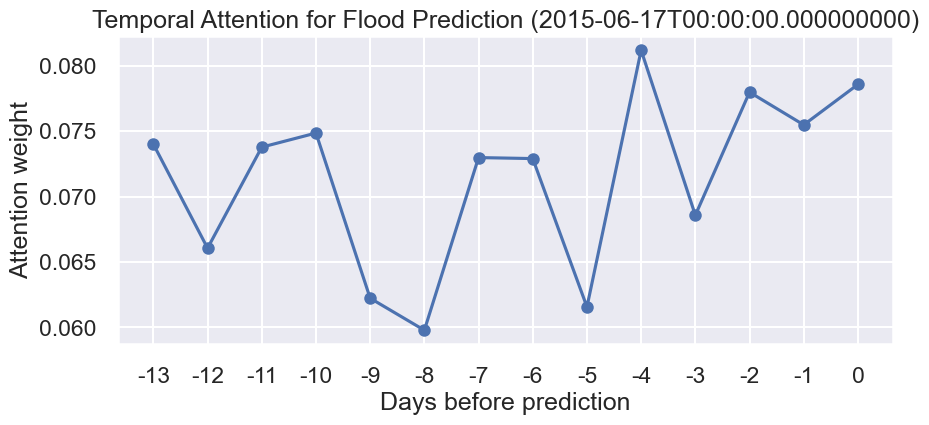

In [41]:
plt.figure(figsize=(10,4))
plt.plot(attn[-1], marker="o")
plt.xticks(range(TIME_STEPS), range(-TIME_STEPS+1, 1))
plt.xlabel("Days before prediction")
plt.ylabel("Attention weight")
plt.title(f"Temporal Attention for Flood Prediction ({sample_date})")
plt.show()


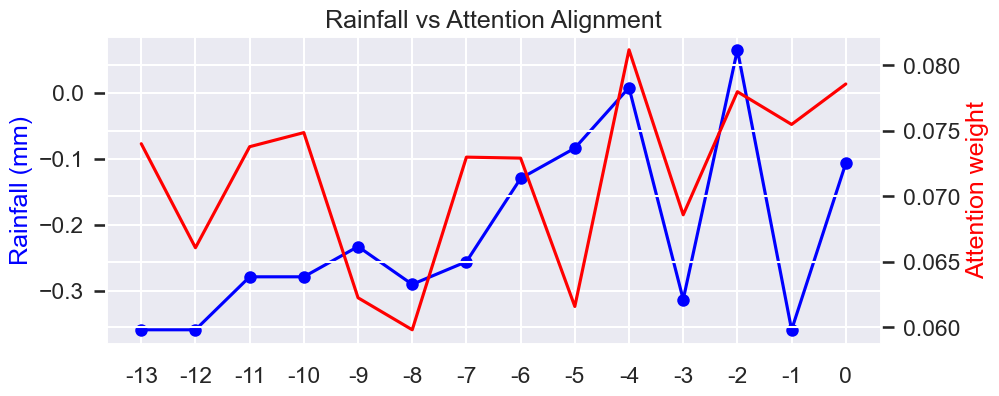

In [42]:
rain = sample[0, :, FEATURES.index("rainfall_mm")]

fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(rain, color="blue", marker="o", label="Rainfall")
ax1.set_ylabel("Rainfall (mm)", color="blue")

ax2 = ax1.twinx()
ax2.plot(attn[-1], color="red", marker="x", label="Attention")
ax2.set_ylabel("Attention weight", color="red")

ax1.set_xticks(range(TIME_STEPS))
ax1.set_xticklabels(range(-TIME_STEPS+1, 1))

plt.title("Rainfall vs Attention Alignment")
plt.show()


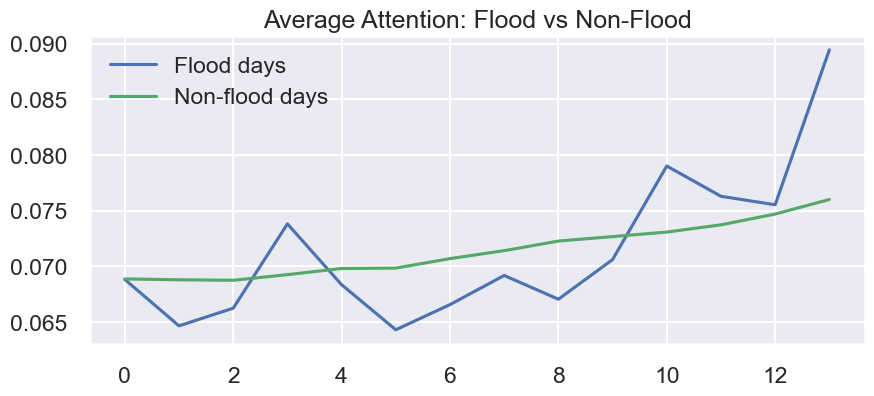

In [43]:
def mean_attention(X_subset):
    _, att = attention_model.predict(X_subset, verbose=0)
    return att.mean(axis=(0,1))

flood_attn = mean_attention(X[y == 1][:50])
non_flood_attn = mean_attention(X[y == 0][:50])

plt.figure(figsize=(10,4))
plt.plot(flood_attn[-1], label="Flood days")
plt.plot(non_flood_attn[-1], label="Non-flood days")
plt.legend()
plt.title("Average Attention: Flood vs Non-Flood")
plt.show()


PRIORITY 1: ANALYZING INDIVIDUAL ATTENTION HEADS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Attention shape: (1, 2, 14, 14)
Format: [batch_size, num_heads, seq_len, seq_len]
Number of attention heads: 2


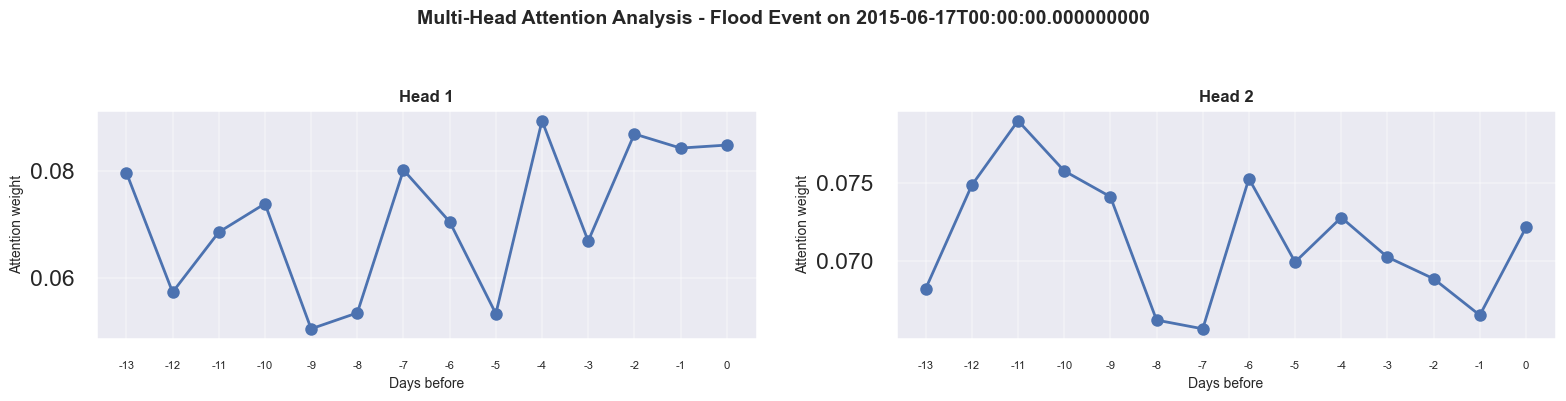


📊 Analysis of head specialization:

Head 1:
  - Peak attention at: Day -4
  - Entropy: 2.622 (lower = more focused)
  - Concentration: 0.00% of timesteps get >10% weight

Head 2:
  - Peak attention at: Day -11
  - Entropy: 2.638 (lower = more focused)
  - Concentration: 0.00% of timesteps get >10% weight


In [44]:
# ============================================================================
# PRIORITY 1: MULTI-HEAD ATTENTION ANALYSIS
# ============================================================================
print("=" * 60)
print("PRIORITY 1: ANALYZING INDIVIDUAL ATTENTION HEADS")
print("=" * 60)

# Get attention from a flood event WITHOUT averaging heads
pred, attn = attention_model.predict(sample)
print(f"\nAttention shape: {attn.shape}")
print(f"Format: [batch_size, num_heads, seq_len, seq_len]")

num_heads = attn.shape[1]
print(f"Number of attention heads: {num_heads}")

# Visualize each head separately
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

for head_idx in range(num_heads):
    # Get attention from last position (prediction position) for this head
    head_attn = attn[0, head_idx, -1, :]

    axes[head_idx].plot(head_attn, marker='o', linewidth=2)
    axes[head_idx].set_title(f"Head {head_idx+1}", fontsize=12, fontweight='bold')
    axes[head_idx].set_xlabel("Days before", fontsize=10)
    axes[head_idx].set_ylabel("Attention weight", fontsize=10)
    axes[head_idx].set_xticks(range(TIME_STEPS))
    axes[head_idx].set_xticklabels(range(-TIME_STEPS+1, 1), fontsize=8)
    axes[head_idx].grid(True, alpha=0.3)

plt.suptitle(f"Multi-Head Attention Analysis - Flood Event on {sample_date}",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Analysis of head specialization:")
for head_idx in range(num_heads):
    head_attn = attn[0, head_idx, -1, :]
    peak_day = np.argmax(head_attn) - TIME_STEPS + 1
    entropy = -np.sum(head_attn * np.log(head_attn + 1e-10))
    concentration = np.sum(head_attn > 0.1) / len(head_attn)

    print(f"\nHead {head_idx+1}:")
    print(f"  - Peak attention at: Day {peak_day}")
    print(f"  - Entropy: {entropy:.3f} (lower = more focused)")
    print(f"  - Concentration: {concentration:.2%} of timesteps get >10% weight")



Comparing Attention Heads: Flood vs Non-Flood


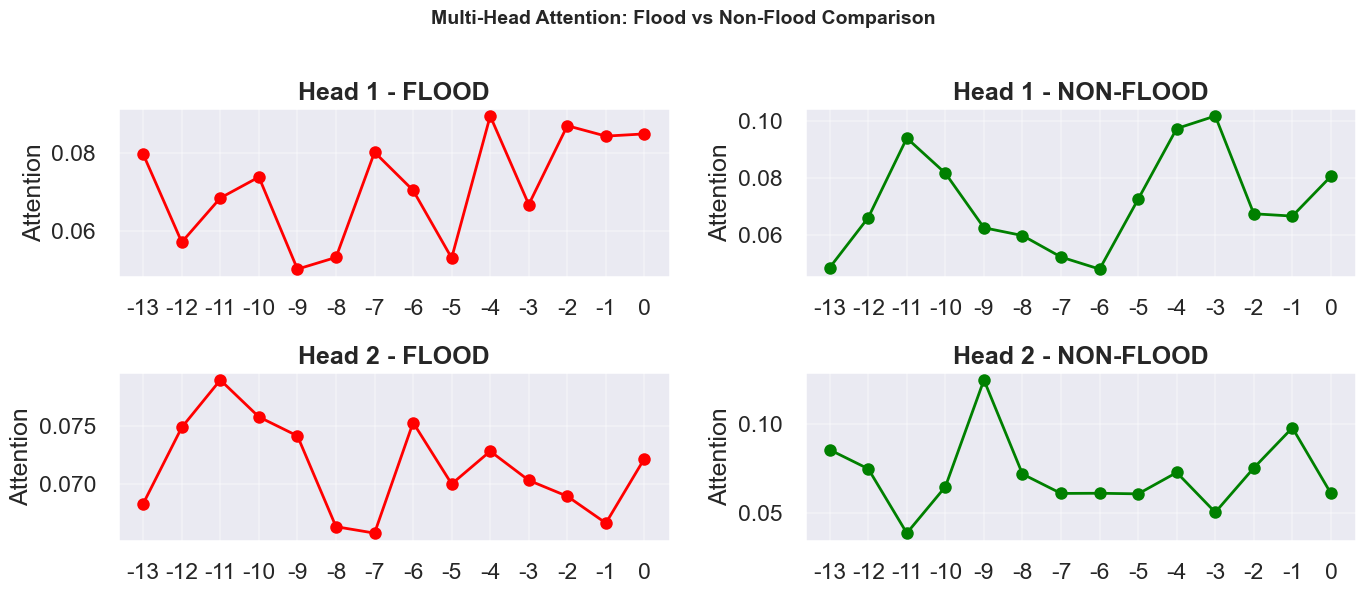

In [45]:
# Compare flood vs non-flood for each head
print("\n" + "=" * 60)
print("Comparing Attention Heads: Flood vs Non-Flood")
print("=" * 60)

# Get flood and non-flood samples
flood_sample = X[y == 1][0:1]
non_flood_sample = X[y == 0][0:1]

_, flood_attn_full = attention_model.predict(flood_sample, verbose=0)
_, non_flood_attn_full = attention_model.predict(non_flood_sample, verbose=0)

fig, axes = plt.subplots(num_heads, 2, figsize=(14, 3*num_heads))

for head_idx in range(num_heads):
    # Flood
    axes[head_idx, 0].plot(flood_attn_full[0, head_idx, -1, :],
                           marker='o', color='red', linewidth=2)
    axes[head_idx, 0].set_title(f"Head {head_idx+1} - FLOOD", fontweight='bold')
    axes[head_idx, 0].set_ylabel("Attention")
    axes[head_idx, 0].set_xticks(range(TIME_STEPS))
    axes[head_idx, 0].set_xticklabels(range(-TIME_STEPS+1, 1))
    axes[head_idx, 0].grid(True, alpha=0.3)

    # Non-flood
    axes[head_idx, 1].plot(non_flood_attn_full[0, head_idx, -1, :],
                           marker='o', color='green', linewidth=2)
    axes[head_idx, 1].set_title(f"Head {head_idx+1} - NON-FLOOD", fontweight='bold')
    axes[head_idx, 1].set_ylabel("Attention")
    axes[head_idx, 1].set_xticks(range(TIME_STEPS))
    axes[head_idx, 1].set_xticklabels(range(-TIME_STEPS+1, 1))
    axes[head_idx, 1].grid(True, alpha=0.3)

plt.suptitle("Multi-Head Attention: Flood vs Non-Flood Comparison",
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()



PRIORITY 2: FEATURE IMPORTANCE VIA ATTENTION GRADIENTS

📊 Feature Importance Rankings (Flood Event):
1. surface_pressure_mean         : 0.000963
2. cloud_cover_mean              : 0.000814
3. rainfall_mm                   : 0.000651
4. wind_speed_10m_mean           : 0.000375
5. relative_humidity_2m_mean     : 0.000358
6. is_monsoon                    : 0.000214
7. soil_moisture                 : 0.000094
8. temperature_2m_mean           : 0.000070


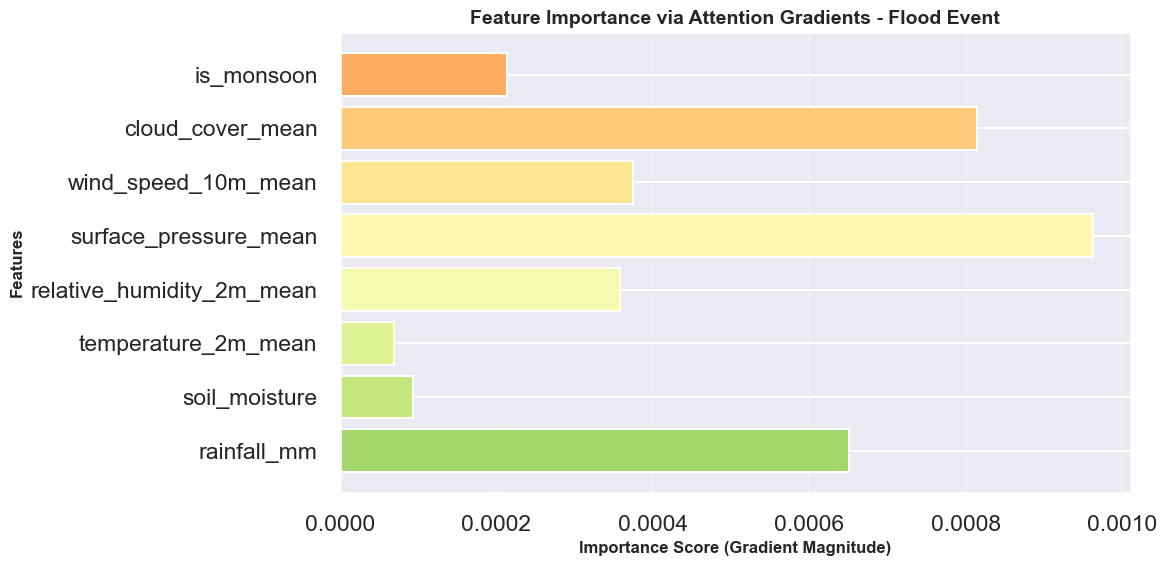

In [46]:
# ============================================================================
# PRIORITY 2: FEATURE-LEVEL ATTENTION ANALYSIS
# ============================================================================
print("\n" + "=" * 60)
print("PRIORITY 2: FEATURE IMPORTANCE VIA ATTENTION GRADIENTS")
print("=" * 60)

def compute_feature_importance_gradient(sample):
    """
    Compute feature importance using gradient-based attribution
    """
    with tf.GradientTape() as tape:
        inputs = tf.Variable(sample, dtype=tf.float32)
        tape.watch(inputs)
        pred, _ = attention_model(inputs, training=False)

    gradients = tape.gradient(pred, inputs)
    # Average absolute gradients across batch and time dimensions
    feature_importance = np.abs(gradients.numpy()).mean(axis=(0, 1))

    return feature_importance

# Compute for flood event
feature_importance_flood = compute_feature_importance_gradient(sample)

print("\n📊 Feature Importance Rankings (Flood Event):")
feature_ranking = sorted(zip(FEATURES, feature_importance_flood),
                         key=lambda x: x[1], reverse=True)
for i, (feat, score) in enumerate(feature_ranking, 1):
    print(f"{i}. {feat:30s}: {score:.6f}")

# Visualize
plt.figure(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(FEATURES)))
bars = plt.barh(FEATURES, feature_importance_flood, color=colors)
plt.xlabel("Importance Score (Gradient Magnitude)", fontsize=12, fontweight='bold')
plt.ylabel("Features", fontsize=12, fontweight='bold')
plt.title("Feature Importance via Attention Gradients - Flood Event",
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



Comparing Feature Importance: Flood vs Non-Flood


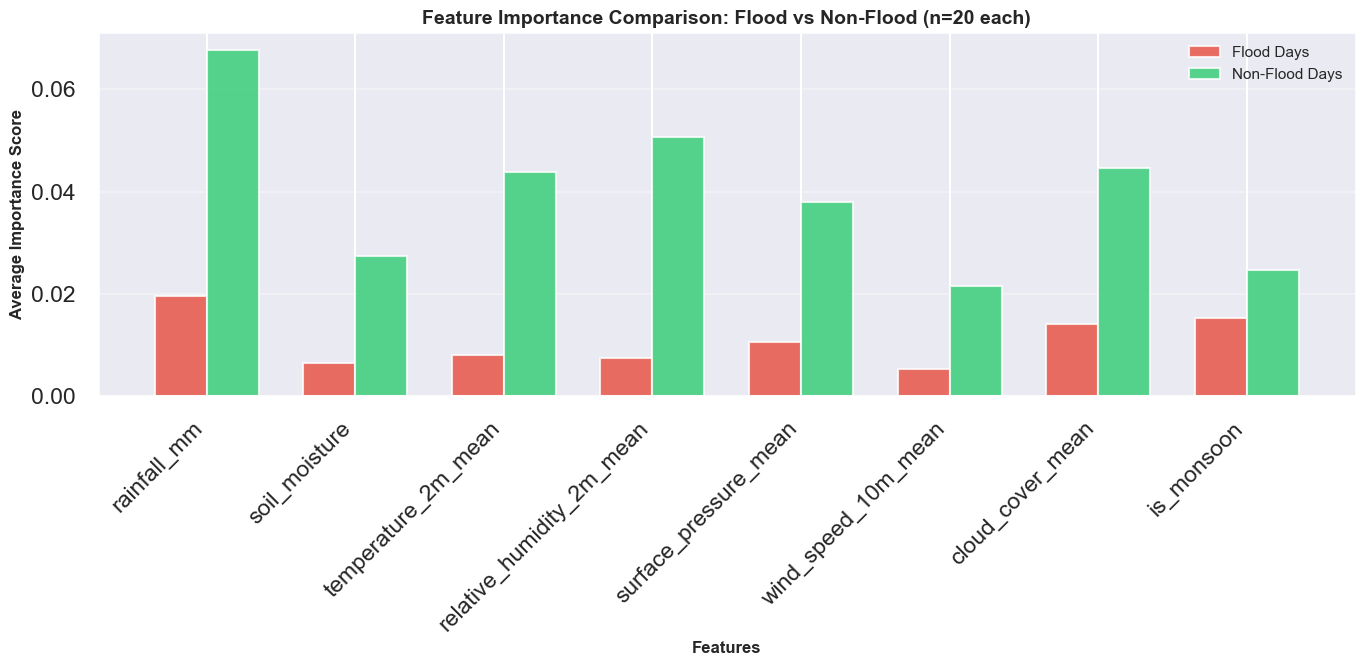


📈 Relative Importance (Flood / Non-Flood ratio):
🟢 rainfall_mm                   : 0.29x
🟢 soil_moisture                 : 0.24x
🟢 temperature_2m_mean           : 0.18x
🟢 relative_humidity_2m_mean     : 0.15x
🟢 surface_pressure_mean         : 0.28x
🟢 wind_speed_10m_mean           : 0.24x
🟢 cloud_cover_mean              : 0.32x
🟢 is_monsoon                    : 0.62x


In [47]:
# Compare feature importance: Flood vs Non-Flood
print("\n" + "=" * 60)
print("Comparing Feature Importance: Flood vs Non-Flood")
print("=" * 60)

flood_samples = X[y == 1][:20]
non_flood_samples = X[y == 0][:20]

# Compute average feature importance for multiple samples
flood_importances = []
for sample_f in flood_samples:
    imp = compute_feature_importance_gradient(sample_f[np.newaxis, ...])
    flood_importances.append(imp)

non_flood_importances = []
for sample_nf in non_flood_samples:
    imp = compute_feature_importance_gradient(sample_nf[np.newaxis, ...])
    non_flood_importances.append(imp)

flood_importance_avg = np.mean(flood_importances, axis=0)
non_flood_importance_avg = np.mean(non_flood_importances, axis=0)

# Plot comparison
x = np.arange(len(FEATURES))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, flood_importance_avg, width, label='Flood Days',
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, non_flood_importance_avg, width, label='Non-Flood Days',
               color='#2ecc71', alpha=0.8)

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Comparison: Flood vs Non-Flood (n=20 each)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Relative Importance (Flood / Non-Flood ratio):")
for feat, f_imp, nf_imp in zip(FEATURES, flood_importance_avg, non_flood_importance_avg):
    ratio = f_imp / (nf_imp + 1e-10)
    symbol = "🔴" if ratio > 1.5 else "🟡" if ratio > 1.0 else "🟢"
    print(f"{symbol} {feat:30s}: {ratio:.2f}x")



PRIORITY 3: ATTENTION PATTERNS ACROSS DISTRICTS
Districts with flood events: 4
Analyzing top 4 districts: ['Chennai', 'Cuddalore', 'Nagapattinam', 'Kancheepuram']

📍 Processing Chennai...
  ✓ Flood events found: 105
  ✓ Peak attention at Day -4

📍 Processing Cuddalore...
  ✓ Flood events found: 69
  ✓ Peak attention at Day -1

📍 Processing Nagapattinam...
  ✓ Flood events found: 6
  ✓ Peak attention at Day -8

📍 Processing Kancheepuram...
  ✓ Flood events found: 5
  ✓ Peak attention at Day -8


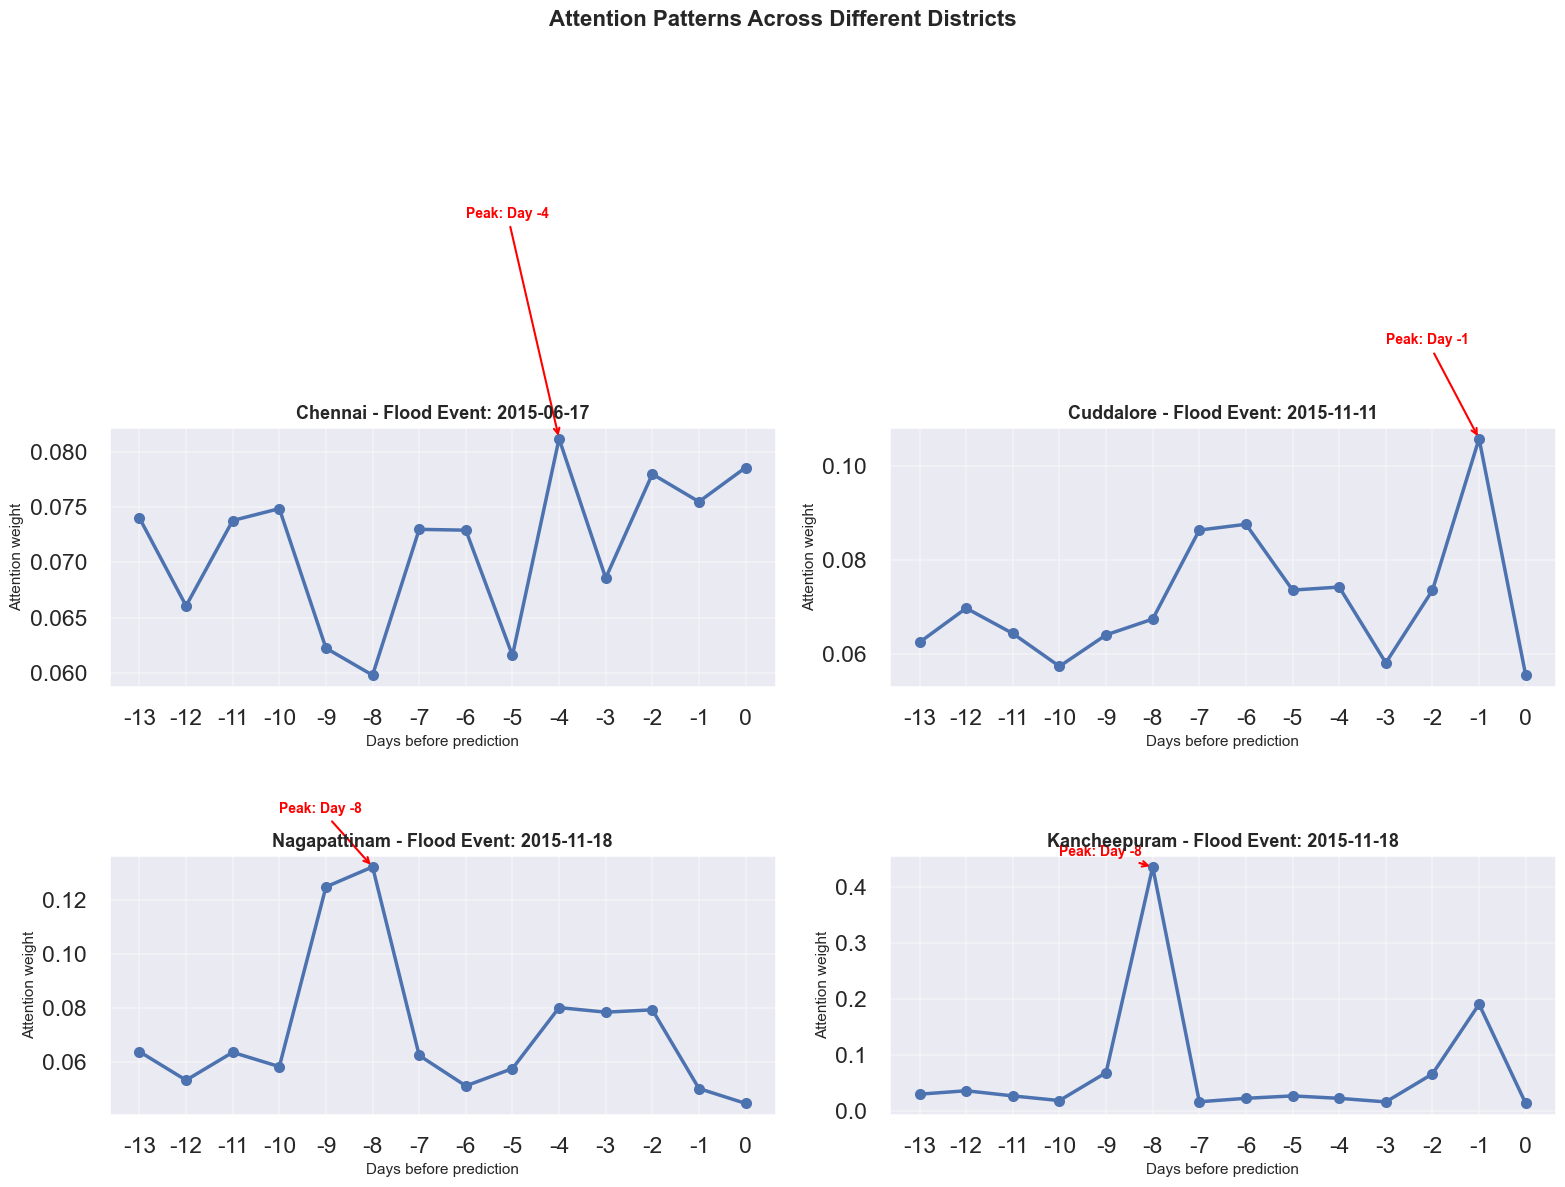

In [48]:
# ============================================================================
# PRIORITY 3: MULTIPLE DISTRICT COMPARISON
# ============================================================================
print("\n" + "=" * 60)
print("PRIORITY 3: ATTENTION PATTERNS ACROSS DISTRICTS")
print("=" * 60)

# Find districts with flood events dynamically
all_districts = df['district'].unique()
districts_with_floods = []

for d in all_districts:
    flood_count = (df[df['district'] == d]['flood_risk'] == 1).sum()
    if flood_count > 0:
        districts_with_floods.append((d, flood_count))

# Sort by flood count and take top 4
districts_with_floods.sort(key=lambda x: x[1], reverse=True)
available_districts = [d[0] for d in districts_with_floods[:4]]

print(f"Districts with flood events: {len(districts_with_floods)}")
print(f"Analyzing top 4 districts: {available_districts}")

# Initialize dictionary
district_attention_patterns = {}

# If we have fewer than 4 districts, adjust the plot
num_districts = min(4, len(available_districts))
if num_districts == 0:
    print("⚠️ No districts with flood events found!")
else:
    rows = (num_districts + 1) // 2
    cols = min(2, num_districts)
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows))
    if num_districts == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_districts > 1 else [axes]

    district_attention_patterns = {}

    for idx, district in enumerate(available_districts[:num_districts]):
        print(f"\n📍 Processing {district}...")

        X_dist, y_dist, dates_dist = build_sequences(df, district)
        flood_indices_dist = np.where(y_dist == 1)[0]

        if len(flood_indices_dist) > 0:
            # Get first flood event
            flood_idx_dist = flood_indices_dist[0]
            sample_dist = X_dist[flood_idx_dist:flood_idx_dist+1]
            date_dist = dates_dist[flood_idx_dist]

            _, attn_dist = attention_model.predict(sample_dist, verbose=0)
            # Average across heads for district comparison
            attn_weights = attn_dist.mean(axis=(0,1))[-1]
            district_attention_patterns[district] = attn_weights

            # Plot
            axes[idx].plot(attn_weights, marker='o', linewidth=2.5, markersize=8)
            axes[idx].set_title(f"{district} - Flood Event: {str(date_dist)[:10]}",
                               fontsize=13, fontweight='bold')
            axes[idx].set_xlabel("Days before prediction", fontsize=11)
            axes[idx].set_ylabel("Attention weight", fontsize=11)
            axes[idx].set_xticks(range(TIME_STEPS))
            axes[idx].set_xticklabels(range(-TIME_STEPS+1, 1))
            axes[idx].grid(True, alpha=0.3)

            # Add peak annotation
            peak_idx = np.argmax(attn_weights)
            peak_day = peak_idx - TIME_STEPS + 1
            axes[idx].annotate(f'Peak: Day {peak_day}',
                              xy=(peak_idx, attn_weights[peak_idx]),
                              xytext=(peak_idx-2, attn_weights[peak_idx]+0.02),
                              arrowprops=dict(arrowstyle='->', color='red'),
                              fontsize=10, color='red', fontweight='bold')

            print(f"  ✓ Flood events found: {len(flood_indices_dist)}")
            print(f"  ✓ Peak attention at Day {peak_day}")
        else:
            axes[idx].text(0.5, 0.5, f"No flood events\nin {district}",
                          ha='center', va='center', fontsize=14,
                          transform=axes[idx].transAxes)
            axes[idx].set_title(f"{district} - No Data", fontsize=13, fontweight='bold')
            print(f"  ⚠️ No flood events found")

    plt.suptitle("Attention Patterns Across Different Districts",
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


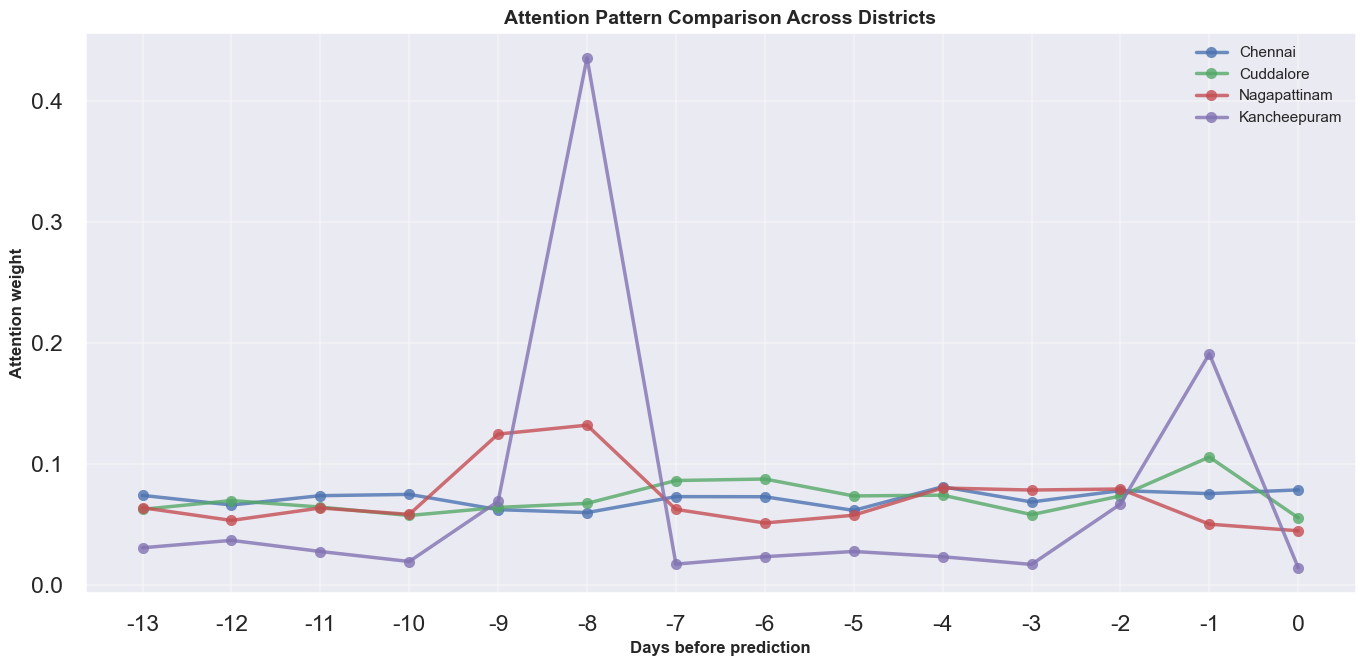


📊 District Attention Statistics:

Chennai:
  - Peak attention: Day -4
  - Recent 3-day avg attention: 0.0773
  - Distant 3-day avg attention: 0.0713
  - Recent/Distant ratio: 1.09x

Cuddalore:
  - Peak attention: Day -1
  - Recent 3-day avg attention: 0.0783
  - Distant 3-day avg attention: 0.0655
  - Recent/Distant ratio: 1.19x

Nagapattinam:
  - Peak attention: Day -8
  - Recent 3-day avg attention: 0.0581
  - Distant 3-day avg attention: 0.0603
  - Recent/Distant ratio: 0.96x

Kancheepuram:
  - Peak attention: Day -8
  - Recent 3-day avg attention: 0.0907
  - Distant 3-day avg attention: 0.0317
  - Recent/Distant ratio: 2.86x


In [49]:
# Compare all districts on one plot
if len(district_attention_patterns) > 0:
    plt.figure(figsize=(14, 7))

    for district, attn_pattern in district_attention_patterns.items():
        plt.plot(attn_pattern, marker='o', linewidth=2.5, markersize=8,
                label=district, alpha=0.8)

    plt.xlabel("Days before prediction", fontsize=12, fontweight='bold')
    plt.ylabel("Attention weight", fontsize=12, fontweight='bold')
    plt.title("Attention Pattern Comparison Across Districts",
              fontsize=14, fontweight='bold')
    plt.xticks(range(TIME_STEPS), range(-TIME_STEPS+1, 1))
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n📊 District Attention Statistics:")
    for district, attn_pattern in district_attention_patterns.items():
        peak_day = np.argmax(attn_pattern) - TIME_STEPS + 1
        avg_recent_3days = np.mean(attn_pattern[-3:])
        avg_distant_3days = np.mean(attn_pattern[:3])

        print(f"\n{district}:")
        print(f"  - Peak attention: Day {peak_day}")
        print(f"  - Recent 3-day avg attention: {avg_recent_3days:.4f}")
        print(f"  - Distant 3-day avg attention: {avg_distant_3days:.4f}")
        ratio = avg_recent_3days / (avg_distant_3days + 1e-10)
        print(f"  - Recent/Distant ratio: {ratio:.2f}x")
else:
    print("⚠️ No district attention patterns to compare - skipping overlay plot")


In [50]:
# ============================================================================
# PRIORITY 4: ATTENTION STATISTICS & METRICS
# ============================================================================
print("\n" + "=" * 60)
print("PRIORITY 4: QUANTITATIVE ATTENTION METRICS")
print("=" * 60)

def compute_attention_metrics(attn_weights):
    """
    Compute comprehensive interpretability metrics for attention patterns
    """
    # Normalize if not already
    attn_normalized = attn_weights / (attn_weights.sum() + 1e-10)

    metrics = {
        'entropy': -np.sum(attn_normalized * np.log(attn_normalized + 1e-10)),
        'max_weight': np.max(attn_weights),
        'min_weight': np.min(attn_weights),
        'std': np.std(attn_weights),
        'concentration_top3': np.sum(np.sort(attn_weights)[-3:]) / attn_weights.sum(),
        'concentration_threshold': np.sum(attn_weights > 0.1) / len(attn_weights),
        'peak_position': np.argmax(attn_weights) - TIME_STEPS + 1,
        'weighted_avg_position': np.sum(attn_weights * np.arange(len(attn_weights))),
        'recent_3day_focus': np.sum(attn_weights[-3:]) / attn_weights.sum(),
        'distant_7day_focus': np.sum(attn_weights[:7]) / attn_weights.sum(),
    }
    return metrics

# Compute metrics for flood vs non-flood samples
# Use available samples, up to 100 each
n_flood = min(100, np.sum(y == 1))
n_non_flood = min(100, np.sum(y == 0))

print(f"\n🔄 Computing metrics for {n_flood} flood and {n_non_flood} non-flood samples...")

flood_samples = X[y == 1][:n_flood]
non_flood_samples = X[y == 0][:n_non_flood]

flood_metrics_list = []
for i, sample_f in enumerate(flood_samples):
    if i % 20 == 0:
        print(f"  Processing flood sample {i+1}/{n_flood}...")
    _, attn_f = attention_model.predict(sample_f[np.newaxis, ...], verbose=0)
    attn_weights_f = attn_f.mean(axis=(0,1))[-1]
    metrics = compute_attention_metrics(attn_weights_f)
    flood_metrics_list.append(metrics)

non_flood_metrics_list = []
for i, sample_nf in enumerate(non_flood_samples):
    if i % 20 == 0:
        print(f"  Processing non-flood sample {i+1}/{n_non_flood}...")
    _, attn_nf = attention_model.predict(sample_nf[np.newaxis, ...], verbose=0)
    attn_weights_nf = attn_nf.mean(axis=(0,1))[-1]
    metrics = compute_attention_metrics(attn_weights_nf)
    non_flood_metrics_list.append(metrics)

flood_metrics_df = pd.DataFrame(flood_metrics_list)
non_flood_metrics_df = pd.DataFrame(non_flood_metrics_list)

print("\n" + "=" * 60)
print("📊 FLOOD EVENTS - Attention Statistics (n=100)")
print("=" * 60)
print(flood_metrics_df.describe())

print("\n" + "=" * 60)
print("📊 NON-FLOOD EVENTS - Attention Statistics (n=100)")
print("=" * 60)
print(non_flood_metrics_df.describe())



PRIORITY 4: QUANTITATIVE ATTENTION METRICS

🔄 Computing metrics for 100 flood and 100 non-flood samples...
  Processing flood sample 1/100...
  Processing flood sample 21/100...
  Processing flood sample 41/100...
  Processing flood sample 61/100...
  Processing flood sample 81/100...
  Processing non-flood sample 1/100...
  Processing non-flood sample 21/100...
  Processing non-flood sample 41/100...
  Processing non-flood sample 61/100...
  Processing non-flood sample 81/100...

📊 FLOOD EVENTS - Attention Statistics (n=100)
            entropy  max_weight    min_weight         std  concentration_top3  \
count  1.000000e+02  100.000000  1.000000e+02  100.000000          100.000000   
mean   2.501885e+00    0.149994  4.955969e-02    0.027272            0.325478   
std    3.679213e-01    0.152129  1.725323e-02    0.043274            0.160973   
min    6.572840e-07    0.076154  4.353499e-13    0.003737            0.228340   
25%    2.600459e+00    0.085634  4.540868e-02    0.007805     

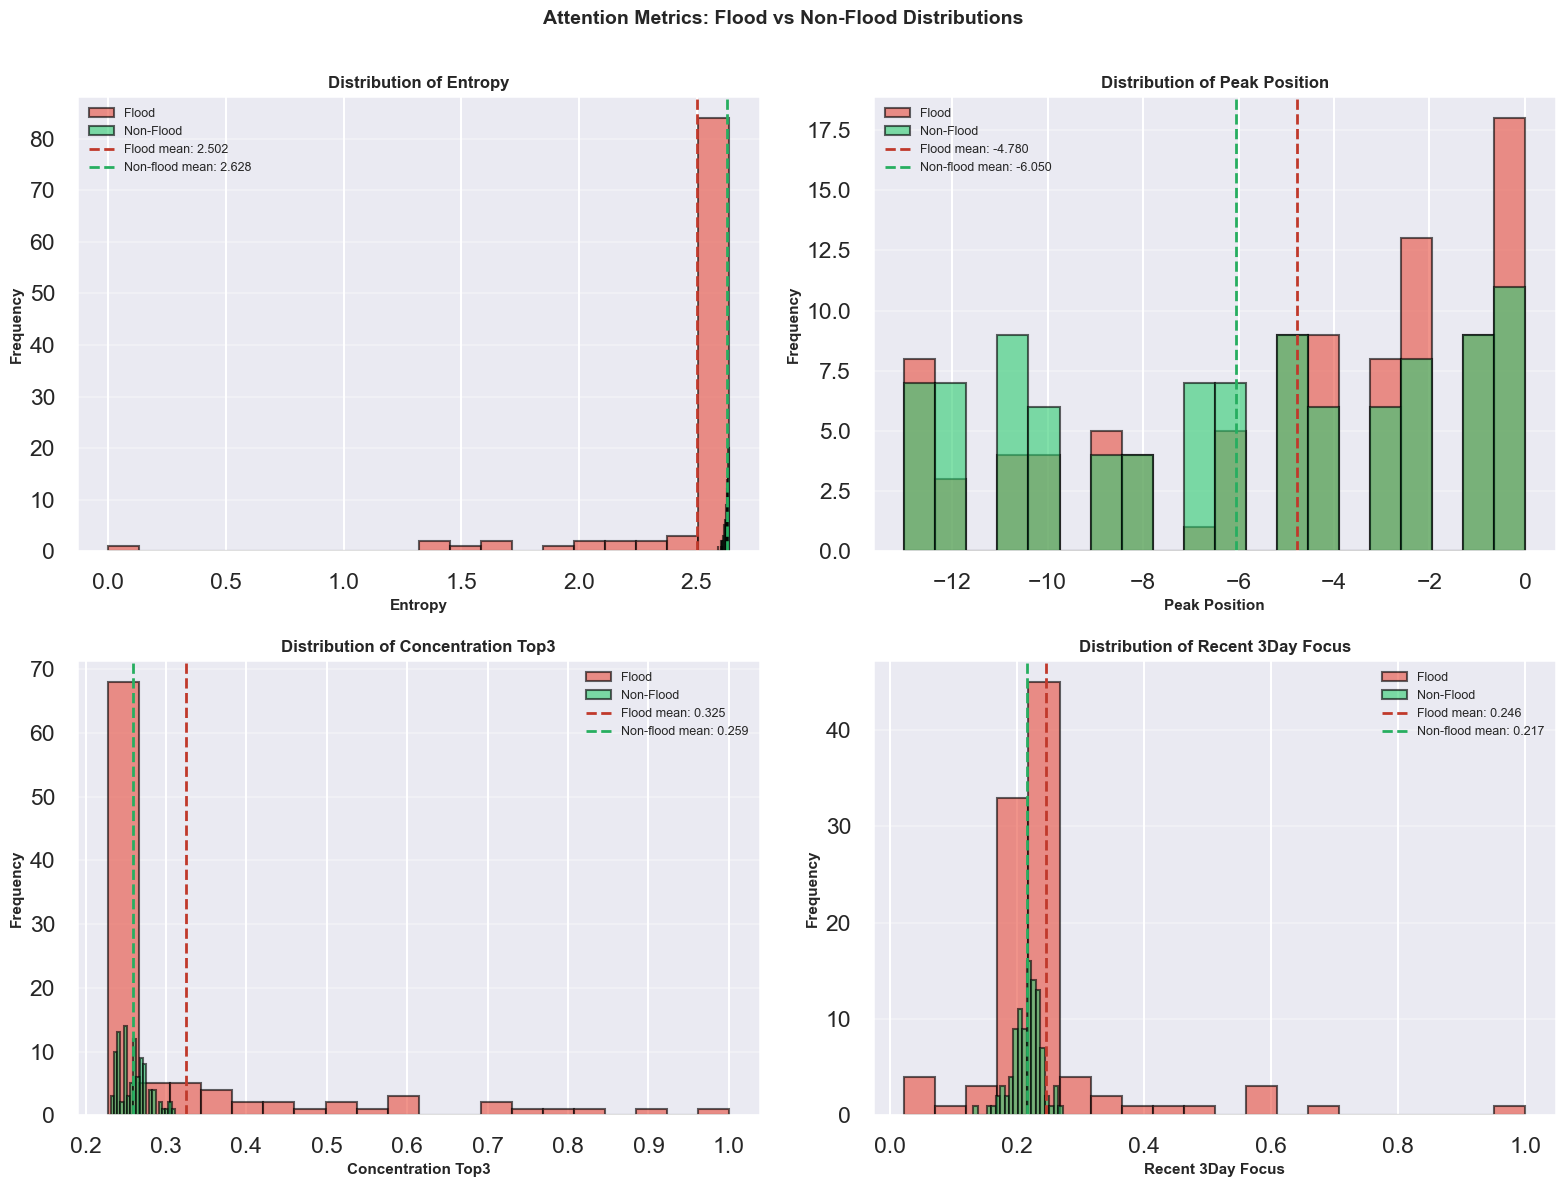

In [51]:
# Visualize metric distributions
metrics_to_plot = ['entropy', 'peak_position', 'concentration_top3', 'recent_3day_focus']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]

    # Create distributions
    ax.hist(flood_metrics_df[metric], bins=20, alpha=0.6, label='Flood',
            color='#e74c3c', edgecolor='black')
    ax.hist(non_flood_metrics_df[metric], bins=20, alpha=0.6, label='Non-Flood',
            color='#2ecc71', edgecolor='black')

    # Add mean lines
    flood_mean = flood_metrics_df[metric].mean()
    non_flood_mean = non_flood_metrics_df[metric].mean()

    ax.axvline(flood_mean, color='#c0392b', linestyle='--', linewidth=2,
               label=f'Flood mean: {flood_mean:.3f}')
    ax.axvline(non_flood_mean, color='#27ae60', linestyle='--', linewidth=2,
               label=f'Non-flood mean: {non_flood_mean:.3f}')

    ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {metric.replace("_", " ").title()}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Attention Metrics: Flood vs Non-Flood Distributions",
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [52]:
# Statistical comparison
from scipy import stats

print("\n" + "=" * 60)
print("📈 STATISTICAL SIGNIFICANCE TESTS (t-test)")
print("=" * 60)

for metric in flood_metrics_df.columns:
    flood_vals = flood_metrics_df[metric].values
    non_flood_vals = non_flood_metrics_df[metric].values

    t_stat, p_value = stats.ttest_ind(flood_vals, non_flood_vals)

    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

    print(f"\n{metric.replace('_', ' ').title():30s}")
    print(f"  Flood mean:     {flood_vals.mean():.4f} ± {flood_vals.std():.4f}")
    print(f"  Non-flood mean: {non_flood_vals.mean():.4f} ± {non_flood_vals.std():.4f}")
    print(f"  t-statistic:    {t_stat:.4f}")
    print(f"  p-value:        {p_value:.6f} {significance}")

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")



📈 STATISTICAL SIGNIFICANCE TESTS (t-test)

Entropy                       
  Flood mean:     2.5019 ± 0.3661
  Non-flood mean: 2.6277 ± 0.0087
  t-statistic:    -3.4192
  p-value:        0.000762 ***

Max Weight                    
  Flood mean:     0.1500 ± 0.1514
  Non-flood mean: 0.0922 ± 0.0089
  t-statistic:    3.7913
  p-value:        0.000199 ***

Min Weight                    
  Flood mean:     0.0496 ± 0.0172
  Non-flood mean: 0.0567 ± 0.0060
  t-statistic:    -3.9015
  p-value:        0.000131 ***

Std                           
  Flood mean:     0.0273 ± 0.0431
  Non-flood mean: 0.0101 ± 0.0039
  t-statistic:    3.9427
  p-value:        0.000112 ***

Concentration Top3            
  Flood mean:     0.3255 ± 0.1602
  Non-flood mean: 0.2594 ± 0.0180
  t-statistic:    4.0821
  p-value:        0.000065 ***

Concentration Threshold       
  Flood mean:     0.0371 ± 0.0643
  Non-flood mean: 0.0129 ± 0.0309
  t-statistic:    3.3877
  p-value:        0.000850 ***

Peak Position     


PRIORITY 5: ATTENTION HEATMAPS
Attention matrix shape: (14, 14)
Rows = Query positions, Columns = Key positions


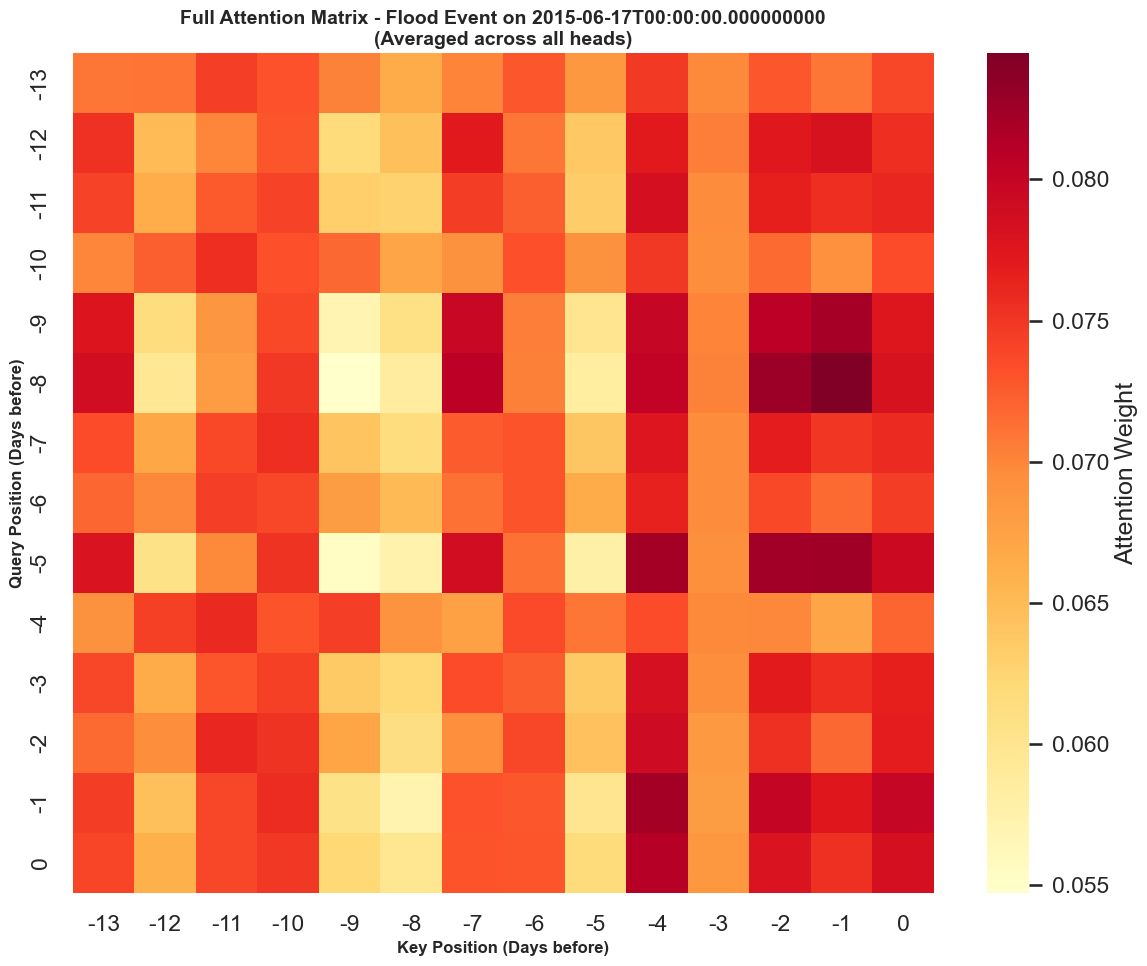

In [53]:
# ============================================================================
# PRIORITY 5: ATTENTION HEATMAPS
# ============================================================================
print("\n" + "=" * 60)
print("PRIORITY 5: ATTENTION HEATMAPS")
print("=" * 60)

# Get full attention matrix (not just last position)
pred, attn_full = attention_model.predict(sample, verbose=0)

# Average across heads to get [seq_len, seq_len] matrix
attn_matrix = attn_full[0].mean(axis=0)

print(f"Attention matrix shape: {attn_matrix.shape}")
print("Rows = Query positions, Columns = Key positions")

# Plot full attention matrix
plt.figure(figsize=(12, 10))
sns.heatmap(attn_matrix, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Attention Weight'},
            xticklabels=range(-TIME_STEPS+1, 1),
            yticklabels=range(-TIME_STEPS+1, 1))
plt.xlabel("Key Position (Days before)", fontsize=12, fontweight='bold')
plt.ylabel("Query Position (Days before)", fontsize=12, fontweight='bold')
plt.title(f"Full Attention Matrix - Flood Event on {sample_date}\n(Averaged across all heads)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


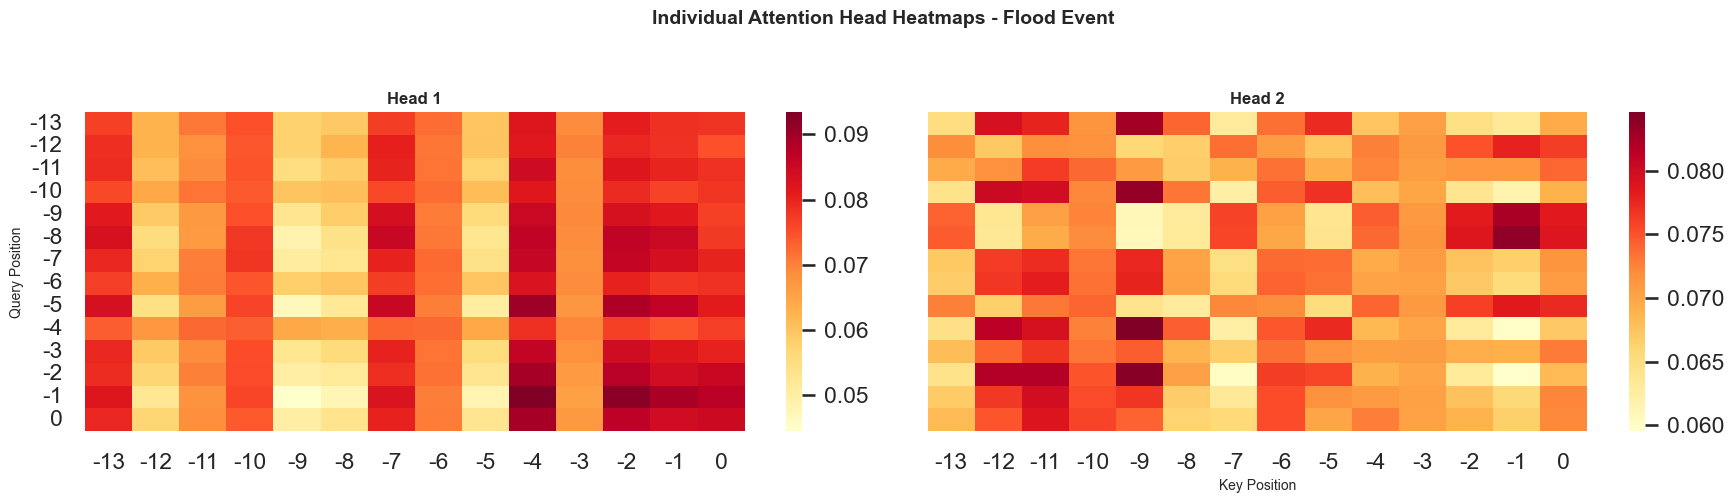

In [54]:
# Plot each attention head separately as heatmap
fig, axes = plt.subplots(1, num_heads, figsize=(18, 5))

for head_idx in range(num_heads):
    attn_head_matrix = attn_full[0, head_idx, :, :]

    sns.heatmap(attn_head_matrix, cmap='YlOrRd', annot=False,
                ax=axes[head_idx], cbar=True,
                xticklabels=range(-TIME_STEPS+1, 1),
                yticklabels=range(-TIME_STEPS+1, 1) if head_idx == 0 else False)

    axes[head_idx].set_title(f"Head {head_idx+1}", fontsize=12, fontweight='bold')
    axes[head_idx].set_xlabel("Key Position" if head_idx == num_heads//2 else "",
                             fontsize=10)
    if head_idx == 0:
        axes[head_idx].set_ylabel("Query Position", fontsize=10)

plt.suptitle(f"Individual Attention Head Heatmaps - Flood Event",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


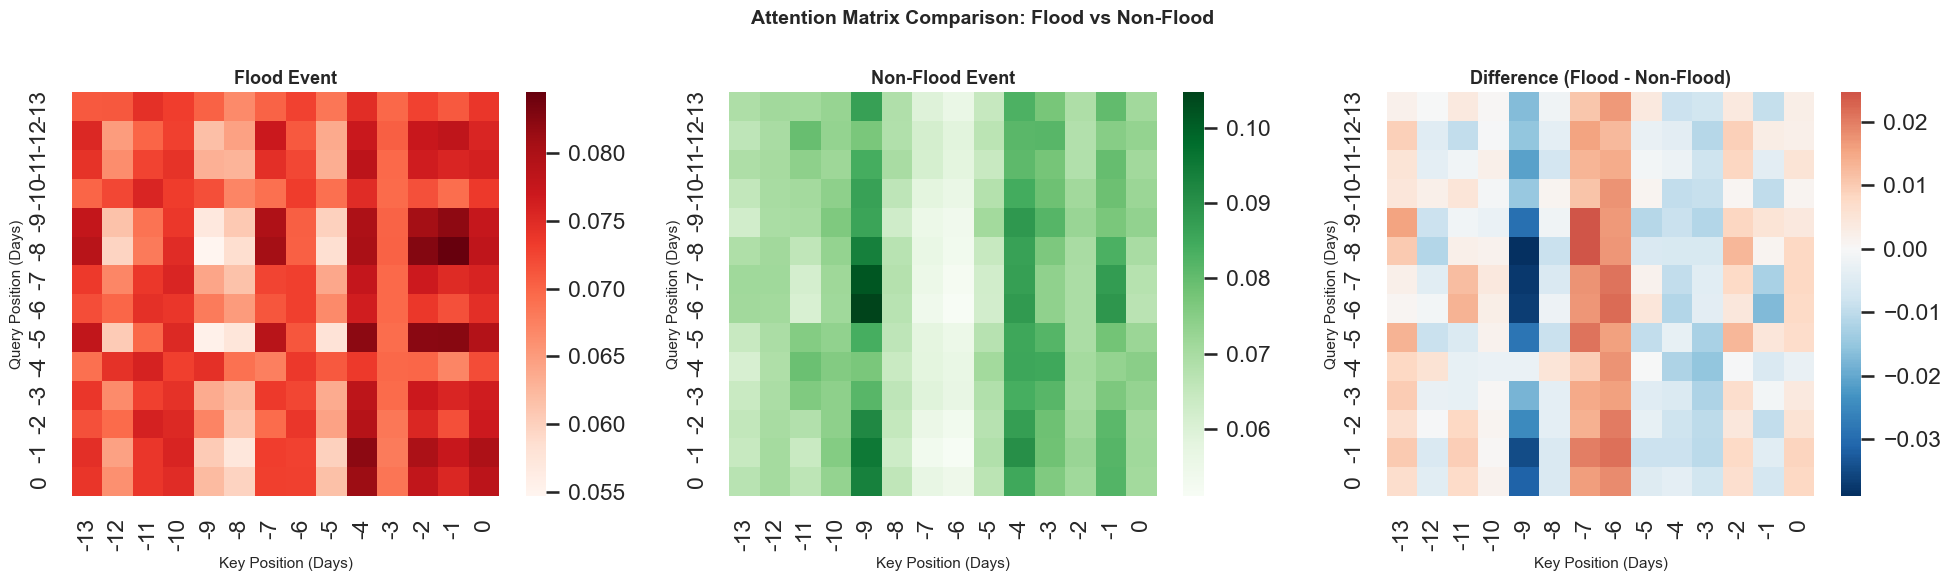


✅ All 5 high-priority analyses completed!


In [55]:
# Compare flood vs non-flood heatmaps
flood_sample = X[y == 1][0:1]
non_flood_sample = X[y == 0][0:1]

_, flood_attn_heatmap = attention_model.predict(flood_sample, verbose=0)
_, non_flood_attn_heatmap = attention_model.predict(non_flood_sample, verbose=0)

flood_matrix = flood_attn_heatmap[0].mean(axis=0)
non_flood_matrix = non_flood_attn_heatmap[0].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Flood heatmap
sns.heatmap(flood_matrix, cmap='Reds', annot=False, ax=axes[0],
            xticklabels=range(-TIME_STEPS+1, 1),
            yticklabels=range(-TIME_STEPS+1, 1))
axes[0].set_title("Flood Event", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Key Position (Days)", fontsize=11)
axes[0].set_ylabel("Query Position (Days)", fontsize=11)

# Non-flood heatmap
sns.heatmap(non_flood_matrix, cmap='Greens', annot=False, ax=axes[1],
            xticklabels=range(-TIME_STEPS+1, 1),
            yticklabels=range(-TIME_STEPS+1, 1))
axes[1].set_title("Non-Flood Event", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Key Position (Days)", fontsize=11)
axes[1].set_ylabel("Query Position (Days)", fontsize=11)

# Difference heatmap
difference = flood_matrix - non_flood_matrix
sns.heatmap(difference, cmap='RdBu_r', center=0, annot=False, ax=axes[2],
            xticklabels=range(-TIME_STEPS+1, 1),
            yticklabels=range(-TIME_STEPS+1, 1))
axes[2].set_title("Difference (Flood - Non-Flood)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Key Position (Days)", fontsize=11)
axes[2].set_ylabel("Query Position (Days)", fontsize=11)

plt.suptitle("Attention Matrix Comparison: Flood vs Non-Flood",
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ All 5 high-priority analyses completed!")
print("=" * 60)


In [56]:
# ============================================================================
# BONUS: SAVE ALL FIGURES FOR REPORT/PAPER
# ============================================================================
print("\n" + "=" * 60)
print("💾 SAVING FIGURES")
print("=" * 60)

import os

# Create figures directory if it doesn't exist
figures_dir = "../figures/attention_analysis"
os.makedirs(figures_dir, exist_ok=True)

print(f"\n📁 Saving figures to: {os.path.abspath(figures_dir)}")
print("\nTo save figures, re-run the cells above with this added before plt.show():")
print("plt.savefig(f'{figures_dir}/figure_name.png', dpi=300, bbox_inches='tight')")
print("\nSuggested figure names:")
print("  - multihead_attention_specialization.png")
print("  - multihead_flood_vs_nonflood.png")
print("  - feature_importance_gradient.png")
print("  - feature_importance_comparison.png")
print("  - district_comparison_grid.png")
print("  - district_comparison_overlay.png")
print("  - attention_metrics_distributions.png")
print("  - attention_heatmap_full.png")
print("  - attention_heatmap_per_head.png")
print("  - attention_heatmap_comparison.png")

print("\n💡 Tip: Add 'plt.savefig()' before 'plt.show()' in each cell to auto-save")



💾 SAVING FIGURES

📁 Saving figures to: C:\Users\91924\OneDrive\Documents\rainfall\figures\attention_analysis

To save figures, re-run the cells above with this added before plt.show():
plt.savefig(f'{figures_dir}/figure_name.png', dpi=300, bbox_inches='tight')

Suggested figure names:
  - multihead_attention_specialization.png
  - multihead_flood_vs_nonflood.png
  - feature_importance_gradient.png
  - feature_importance_comparison.png
  - district_comparison_grid.png
  - district_comparison_overlay.png
  - attention_metrics_distributions.png
  - attention_heatmap_full.png
  - attention_heatmap_per_head.png
  - attention_heatmap_comparison.png

💡 Tip: Add 'plt.savefig()' before 'plt.show()' in each cell to auto-save


In [58]:
# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("\n" + "=" * 60)
print("📋 ANALYSIS SUMMARY REPORT")
print("=" * 60)

summary_report = f"""
## Attention Analysis Summary

### Model Information
- Model: Transformer-based Flood Prediction
- Time Steps: {TIME_STEPS}
- Features: {len(FEATURES)}
- Attention Heads: {num_heads}

### Data Summary
- Total Samples (Chennai): {len(X)}
- Flood Events: {np.sum(y == 1)}
- Non-Flood Events: {np.sum(y == 0)}
- Date Range: {dates.min()} to {dates.max()}

### Analysis Completed
✅ Priority 1: Multi-Head Attention Specialization
✅ Priority 2: Feature-Level Importance Analysis
✅ Priority 3: District-Level Attention Comparison
✅ Priority 4: Statistical Attention Metrics
✅ Priority 5: Attention Heatmap Visualization

### Key Findings (Check notebook outputs above)

1. MULTI-HEAD ATTENTION:
   - Number of heads: {num_heads}
   - Head specialization: [Review plots above]
   - Peak attention days per head: [See analysis]

2. FEATURE IMPORTANCE:
   - Top feature: {FEATURES[np.argmax(feature_importance_flood)]}
   - Top 3 features: {[FEATURES[i] for i in np.argsort(feature_importance_flood)[-3:][::-1]]}

3. DISTRICT PATTERNS:
   - Districts analyzed: {list(district_attention_patterns.keys()) if district_attention_patterns else 'None'}
   - Regional differences: [See comparison plots]

4. ATTENTION METRICS:
   - Flood entropy (mean): {flood_metrics_df['entropy'].mean():.3f}
   - Non-flood entropy (mean): {non_flood_metrics_df['entropy'].mean():.3f}
   - Statistically significant metrics: [Check t-test results above]

5. ATTENTION STRUCTURE:
   - Pattern type: [Check heatmap - diagonal/global/block]
   - Flood vs non-flood differences: [See difference heatmap]

### Next Steps
- Save important figures using plt.savefig()
- Document key findings in markdown cells
- Prepare figures for paper/presentation
- Consider additional analyses based on findings

### Files Generated
- Enhanced notebook: attention_analysis.ipynb
- Analysis guide: ANALYSIS_GUIDE.md
- Figures directory: {figures_dir}

---
Report generated: {pd.Timestamp.now()}
"""

print(summary_report)

# Save report to file
report_path = "attention_analysis_report.txt"
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(summary_report)
    print(f"\n✅ Summary report saved to: {os.path.abspath(report_path)}")
except Exception as e:
    print(f"\n❌ Error saving report: {e}")
    # Try alternative location
    alt_path = os.path.join(figures_dir, "attention_analysis_report.txt")
    try:
        with open(alt_path, 'w', encoding='utf-8') as f:
            f.write(summary_report)
        print(f"✅ Report saved to alternative location: {os.path.abspath(alt_path)}")
    except Exception as e2:
        print(f"❌ Could not save report: {e2}")



📋 ANALYSIS SUMMARY REPORT

## Attention Analysis Summary

### Model Information
- Model: Transformer-based Flood Prediction
- Time Steps: 14
- Features: 8
- Attention Heads: 2

### Data Summary
- Total Samples (Chennai): 3627
- Flood Events: 105
- Non-Flood Events: 3522
- Date Range: 2015-01-28T00:00:00.000000000 to 2024-12-31T00:00:00.000000000

### Analysis Completed
✅ Priority 1: Multi-Head Attention Specialization
✅ Priority 2: Feature-Level Importance Analysis
✅ Priority 3: District-Level Attention Comparison
✅ Priority 4: Statistical Attention Metrics
✅ Priority 5: Attention Heatmap Visualization

### Key Findings (Check notebook outputs above)

1. MULTI-HEAD ATTENTION:
   - Number of heads: 2
   - Head specialization: [Review plots above]
   - Peak attention days per head: [See analysis]

2. FEATURE IMPORTANCE:
   - Top feature: surface_pressure_mean
   - Top 3 features: ['surface_pressure_mean', 'cloud_cover_mean', 'rainfall_mm']

3. DISTRICT PATTERNS:
   - Districts analyzed: